<a href="https://colab.research.google.com/github/goutham3010/Hospital-Readmission-Prediction-System/blob/main/1_Data_Understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [61]:
df=pd.read_csv("hospital_readmission_dataset.csv")
df.head()


,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


In [62]:
print("The shape of dataset is:",df.shape)
print("The no of rows in dataset are:",df.shape[0])
print("The no of columns in dataset are:",df.shape[1])



The shape of dataset is: (8000, 17)
The no of rows in dataset are: 8000
The no of columns in dataset are: 17


In [63]:
print("="*50)
print("The columns in dataset are:")
print("="*50)
for i,column in enumerate(df.columns,start=1):
  print(f"{i}.{column}")

The columns in dataset are:
1.patient_id
2.admission_date
3.season
4.age
5.gender
6.region
7.primary_diagnosis
8.comorbidities_count
9.length_of_stay
10.treatment_type
11.medications_count
12.followup_visits_last_year
13.prev_readmissions
14.insurance_type
15.discharge_disposition
16.readmission_risk_score
17.label


In [64]:
print("="*50)
print("The data about dataset is:")
print("="*50)
df.info()

The data about dataset is:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 8000 non-null   object 
 1   admission_date             8000 non-null   object 
 2   season                     8000 non-null   object 
 3   age                        8000 non-null   int64  
 4   gender                     8000 non-null   object 
 5   region                     8000 non-null   object 
 6   primary_diagnosis          8000 non-null   object 
 7   comorbidities_count        8000 non-null   int64  
 8   length_of_stay             8000 non-null   int64  
 9   treatment_type             8000 non-null   object 
 10  medications_count          8000 non-null   int64  
 11  followup_visits_last_year  8000 non-null   int64  
 12  prev_readmissions          8000 non-null   int64  
 13  insurance_type       

In [65]:
df.describe()

,age,comorbidities_count,length_of_stay,medications_count,followup_visits_last_year,prev_readmissions,readmission_risk_score,label
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000
mean,57.411625,4.318500,7.789125,7.475750,3.638125,1.57250,0.776937,0.772875
std,16.724388,1.358046,1.930252,2.287917,1.630415,0.89196,0.219885,0.419000
min,18.000000,1.000000,3.000000,2.000000,0.000000,0.00000,0.070000,0.000000
25%,46.000000,3.000000,6.000000,6.000000,2.000000,1.00000,0.630000,1.000000
50%,57.000000,4.000000,8.000000,8.000000,4.000000,1.00000,0.860000,1.000000
75%,69.000000,5.000000,9.000000,9.000000,4.000000,2.00000,0.970000,1.000000
max,95.000000,10.000000,15.000000,18.000000,10.000000,5.00000,0.970000,1.000000


In [66]:
df.isnull().sum()

,0
patient_id,0
admission_date,0
season,0
age,0
gender,0
region,0
primary_diagnosis,0
comorbidities_count,0
length_of_stay,0
treatment_type,0


In [48]:
df.describe(include="object")

,season,gender,region,primary_diagnosis,treatment_type,insurance_type,discharge_disposition
count,8000,8000,8000,8000,8000,8000,8000
unique,4,2,5,11,4,4,4
top,Winter,Female,South,Diabetes,Medical,Private,Home Health
freq,2041,4184,1993,1470,3588,3052,6065


In [73]:
df.duplicated().sum()
df[df.duplicated()]

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label


In [44]:
print("="*50)
print("The unique values in gender are:",df['gender'].unique())
print("="*50)
print("The no of male and female are:\n",df['gender'].value_counts())


The unique values in gender are: ['Male' 'Female']
The no of male and female are:
 gender
Female    4184
Male      3816
Name: count, dtype: int64


In [80]:
print(df['label'].value_counts())
print("="*60)
print("The percentage of labels in dataset:",df['label'].value_counts(normalize=True)*100,2)

label
1    6183
0    1817
Name: count, dtype: int64
The percentage of labels in dataset: label
1    77.2875
0    22.7125
Name: proportion, dtype: float64 2


Text(0.5, 1.0, 'Readmissions')

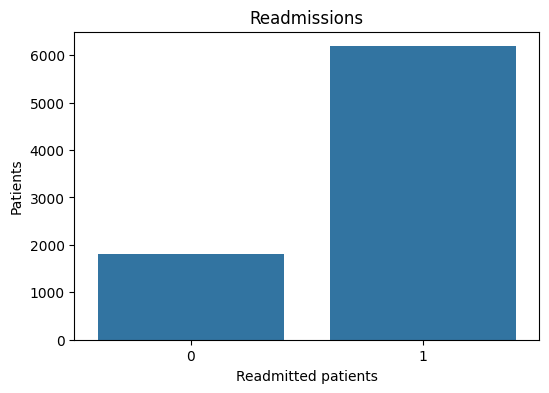

In [84]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x=df['label'])
plt.xlabel("Readmitted patients")
plt.ylabel("Patients")
plt.title("Readmissions")